In [30]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import requests
import warnings
import plotly.express as px
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import time
import json

# prison path from API
# Ask if you want to download new datasets from the API? 
# Set to True if you want to download new datasets, or False if you want to use the existing CSV files in the data folder.
download_new_datasets = (
    input("Do you want to download new datasets from the API? (y/n): ")
    .strip().lower()
    in ["y", "yes"])

if download_new_datasets:
    # AI adoption API links
    prison_data_link = ("https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/crim_pris_age/1.0/*.*.*.*.*?c[freq]=A&"
                        "c[age]=TOTAL,JUVENILE,ADULT&c[sex]=T,M,F&"
                        "c[unit]=P_HTHAB&"
                        "c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE&"
                        "c[TIME_PERIOD]=2023,2022,2021,2020,2019,2018,2017,2016,2015,2014&compress=false&"
                        "format=csvdata&formatVersion=2.0&"
                        "lang=en&labels=name")

    # Downloading the datasets and saving them as CSV files in the data folder
    prison_data_response = requests.get(prison_data_link)

    with open("../data/prison data/Prison_data.csv", "wb") as f:
        f.write(prison_data_response.content)

# Loading the datasets into pandas DataFrames
prison_data_df = pd.read_csv("../data/prison data/Prison_data.csv")
print(f"Prison Data DataFrame shape: {prison_data_df.shape[0]} rows, {prison_data_df.shape[1]} columns")

Prison Data DataFrame shape: 2315 rows, 21 columns


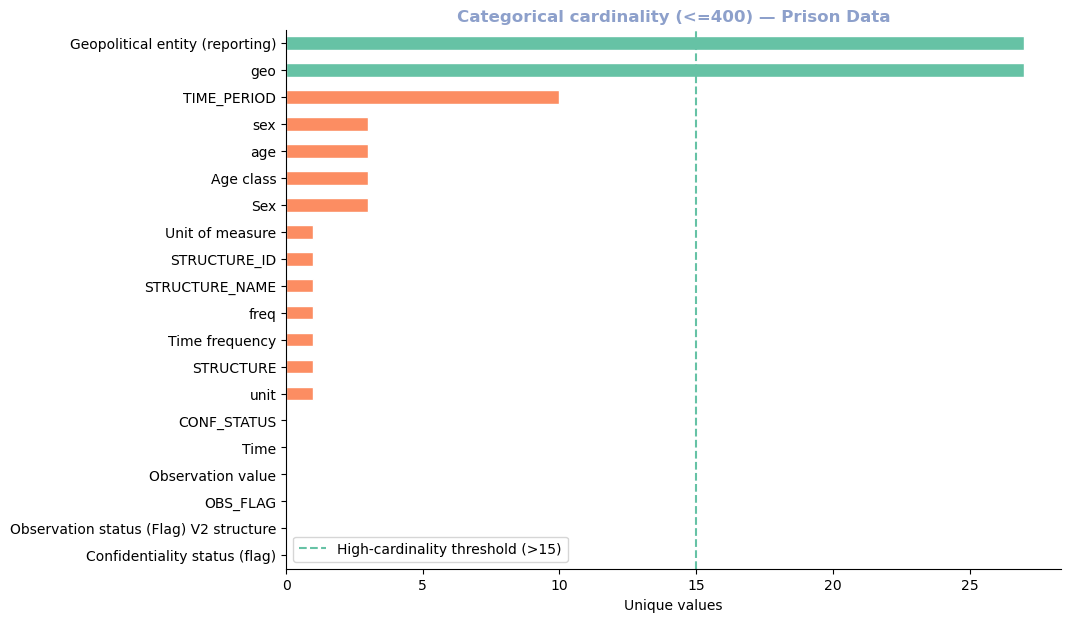

HIGH-CARDINALITY features (excluded from chart):
    'OBS_VALUE': 1942 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data):
  'Confidentiality status (flag)' (0 values): []

  'Observation status (Flag) V2 structure' (0 values): []

  'OBS_FLAG' (0 values): []

  'Observation value' (0 values): []

  'Time' (0 values): []

  'CONF_STATUS' (0 values): []

  'unit' (1 values): ['P_HTHAB']

  'STRUCTURE' (1 values): ['dataflow']

  'Time frequency' (1 values): ['Annual']

  'freq' (1 values): ['A']

  'STRUCTURE_NAME' (1 values): ['Prisoners by age and sex']

  'STRUCTURE_ID' (1 values): ['ESTAT:CRIM_PRIS_AGE(1.0)']

  'Unit of measure' (1 values): ['Per hundred thousand inhabitants']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'age' (3 values): ['ADULT', 'JUVENILE', 'TOTAL']

  'sex' (3 values): ['F', 'M', 'T']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '201

In [31]:
# cardinality of the dataset
YEARS = range(2008, 2024)
PALETTE = sns.color_palette("Set2")
CORAL, STEEL, NAVY = PALETTE[0], PALETTE[1], PALETTE[2]
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object", "category", "bool", "int64", "float64"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(prison_data_df, "Prison Data")

In [32]:
country_codes = {
    "Austria": "AUT", "Belgium": "BEL", "Bulgaria": "BGR", 
    "Croatia": "HRV", "Cyprus": "CYP", "Czechia": "CZE", 
    "Estonia": "EST", "Finland": "FIN", "France": "FRA",
    "Germany": "DEU", "Greece": "GRC", "Hungary": "HUN",
    "Ireland": "IRL", "Italy": "ITA","Denmark": "DNK",
    "Latvia": "LVA", "Romania": "ROU",  "Slovakia": "SVK",
    "Lithuania": "LTU", "Luxembourg": "LUX", "Malta": "MLT",
    "Netherlands": "NLD", "Poland": "POL", "Portugal": "PRT",
    "Slovenia": "SVN", "Spain": "ESP", "Sweden": "SWE",
}
area_km2 = {
    "Albania": 28748, "Austria": 83879, "Belgium": 30689,
    "Bulgaria": 110994, "Croatia": 56594, "Poland": 312696,
    "Cyprus": 9251, "Czechia": 78871, "Denmark": 42952,
    "Estonia": 45339, "Finland": 338455, "France": 643801,
    "Germany": 357596, "Greece": 131957, "Hungary": 93030,
     "Ireland": 70273, "Italy": 302068, "Portugal": 92212,
    "Latvia": 64589, "Switzerland": 41285, "Türkiye": 783562,
    "Lithuania": 65300, "Luxembourg": 2586, "Malta": 316,
    "Romania": 238397, "Slovakia": 49035, "Netherlands": 41865, 
    "Slovenia": 20271, "Spain": 505990, "Sweden": 450295,  
}
# Sessione con retry automatici
session = requests.Session()
retry = Retry(
    total=5,
    backoff_factor=2,                              # attese: 2s, 4s, 8s, 16s, 32s
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=["GET"],
)
session.mount("https://", HTTPAdapter(max_retries=retry))

# Cache su disco — evita di rifare chiamate già riuscite
CACHE_FILE = Path("worldbank_population_cache.json")
if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        _cache = json.load(f)
else:
    _cache = {}
def get_population_world_bank(iso3_code, start_year=2008, end_year=2023):
    cache_key = f"{iso3_code}_{start_year}_{end_year}"
    if cache_key in _cache:
        # converti chiavi anno da str (JSON) a int
        return {int(k): v for k, v in _cache[cache_key].items()}

    url = (
        f"https://api.worldbank.org/v2/country/{iso3_code}/indicator/SP.POP.TOTL"
        f"?format=json&date={start_year}:{end_year}&per_page=100"
    )
    try:
        response = session.get(url, timeout=(15, 90))   # (connect, read)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, list) or len(payload) < 2 or payload[1] is None:
            print(f"[warn] nessun dato per {iso3_code}")
            return {}
        result = {
            int(item["date"]): int(item["value"])
            for item in payload[1]
            if item.get("value") is not None
        }
        # salva in cache
        _cache[cache_key] = result
        with open(CACHE_FILE, "w") as f:
            json.dump(_cache, f)
        return result
    except requests.exceptions.RequestException as e:
        print(f"[warn] errore per {iso3_code}: {e}")
        return {}

country_info = {}
for country, code in country_codes.items():
    country_info[country] = {
        "area_km2": area_km2[country],
        "population_by_year": get_population_world_bank(code, 2008, 2023),
    }
# Manual mapping for regions not in World Bank API
country_info["England and Wales"] = {"area_km2": 151244, "population_by_year": None, "population_fixed": 59641000}
country_info["Scotland (NUTS 2021)"] = {"area_km2": 78803, "population_by_year": None, "population_fixed": 5480000}
country_info["Northern Ireland (UK) (NUTS 2021)"] = {"area_km2": 14333, "population_by_year": None, "population_fixed": 1905000}

# Assign columns after country_info is fully built
prison_data_df["geo"] = prison_data_df["Geopolitical entity (reporting)"].map(country_codes)
prison_data_df["area_km2"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("area_km2")
)
prison_data_df["population_by_year"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_by_year")
)
prison_data_df["population_fixed"] = prison_data_df["Geopolitical entity (reporting)"].map(
    lambda x: country_info.get(x, {}).get("population_fixed")
)

In [34]:
def resolve_population(row):
    if row["population_fixed"] is not None and not (isinstance(row["population_fixed"], float) and pd.isna(row["population_fixed"])):
        return row["population_fixed"]
    pop_dict = row["population_by_year"]
    if isinstance(pop_dict, dict):
        return pop_dict.get(row["TIME_PERIOD"])
    return None
prison_data_df["population_year"] = prison_data_df.apply(resolve_population, axis=1)

prison_data_df["Per hundred thousand inhabitants"] = prison_data_df["OBS_VALUE"].where(prison_data_df["Unit of measure"] == "Per hundred thousand inhabitants")

# For rows with count, calculate rate
missing_rate = prison_data_df["Per hundred thousand inhabitants"].isna()
prison_data_df.loc[missing_rate, "Per hundred thousand inhabitants"] = (prison_data_df.loc[missing_rate, "OBS_VALUE"] * 100000 / prison_data_df.loc[missing_rate, "population_year"]).round(2)

prison_data_df.sample(5)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,age,Age class,sex,Sex,unit,...,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag),area_km2,population_by_year,population_fixed,population_year,Per hundred thousand inhabitants
2269,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,T,Total,P_HTHAB,...,NaN,NaN,NaN,NaN,NaN,92212,"{2023: 10578174, 2022: 10434332, 2021: 1036183...",None,10300300,131.79
398,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,ADULT,Adult,M,Males,P_HTHAB,...,NaN,NaN,NaN,NaN,NaN,302068,"{2023: 58984216, 2022: 59013667, 2021: 5913317...",None,60002252,226.72
1815,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,M,Males,P_HTHAB,...,NaN,NaN,NaN,NaN,NaN,110994,"{2023: 6446596, 2022: 6465097, 2021: 6507301, ...",None,6550696,179.81
1810,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,M,Males,P_HTHAB,...,NaN,NaN,NaN,NaN,NaN,110994,"{2023: 6446596, 2022: 6465097, 2021: 6507301, ...",None,6984225,204.51
1906,dataflow,ESTAT:CRIM_PRIS_AGE(1.0),Prisoners by age and sex,A,Annual,TOTAL,Total,M,Males,P_HTHAB,...,NaN,NaN,NaN,NaN,NaN,56594,"{2023: 3859686, 2022: 3855641, 2021: 3878981, ...",None,3914206,169.55


In [35]:
# Drop columns 
prison_data_df.drop(columns=[
    'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'age', 'sex',
    'Confidentiality status (flag)', 'OBS_FLAG', 'Observation value', 'Time', 'CONF_STATUS',
    'STRUCTURE', 'Observation status (Flag) V2 structure', 'Unit of measure', 'OBS_VALUE',
    'population_by_year', 'population_fixed'], inplace=True)

prison_data_df.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants
399,Adult,Males,ITA,Italy,2018,302068,60148658,234.13
2280,Total,Total,ROU,Romania,2018,238397,19473970,106.46
1994,Total,Males,POL,Poland,2019,312696,37965475,388.13
1090,Juvenile,Males,EST,Estonia,2022,45339,1348840,2.25
977,Juvenile,Females,PRT,Portugal,2016,92212,10325452,2.27


In [36]:
gender_path = Path('../data/Data to export//cleaned_gender_index.csv')
gender_data = pd.read_csv(gender_path)

gender_data = gender_data.melt(
    id_vars='Country', var_name='TIME_PERIOD', value_name='Gender_index'
)
gender_data['TIME_PERIOD'] = gender_data['TIME_PERIOD'].astype(int)
# add a column to prison_data with the gender index for each country and year
prison_data = prison_data_df.merge(
    gender_data,
    left_on=['Geopolitical entity (reporting)', 'TIME_PERIOD'],
    right_on=['Country', 'TIME_PERIOD'],
    how='left'
).drop(columns='Country')
prison_data.sample(5)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Gender_index
1165,Juvenile,Males,ITA,Italy,2018,302068,60148658,26.80,0.706
640,Adult,Total,HUN,Hungary,2021,93030,9630932,230.09,0.688
1921,Total,Males,IRL,Ireland,2015,70273,4701957,135.28,0.807
759,Adult,Total,SVN,Slovenia,2023,20271,2120461,81.86,0.773
1498,Juvenile,Total,ROU,Romania,2017,238397,19588715,10.67,0.708


In [37]:
# We separate the row where the 'Age class' and 'Sex' columns have the value 'Total'
total_values = prison_data[(prison_data['Age class'] == 'Total') | (prison_data['Sex'] == 'Total')]
# then drop them from the original dataset
prison_data.drop(total_values.index, inplace=True)
total_values.head(10)

,Age class,Sex,geo,Geopolitical entity (reporting),TIME_PERIOD,area_km2,population_year,Per hundred thousand inhabitants,Gender_index
514,Adult,Total,AUT,Austria,2014,83879,8546356,122.77,0.7266
515,Adult,Total,AUT,Austria,2015,83879,8642699,121.15,0.7330
516,Adult,Total,AUT,Austria,2016,83879,8736668,118.43,0.7160
517,Adult,Total,AUT,Austria,2017,83879,8797566,120.20,0.7090
518,Adult,Total,AUT,Austria,2018,83879,8840521,123.95,0.7180
519,Adult,Total,AUT,Austria,2019,83879,8879920,121.88,0.7310
520,Adult,Total,AUT,Austria,2020,83879,8916864,114.13,0.7440
521,Adult,Total,AUT,Austria,2021,83879,8955797,112.87,0.7770
522,Adult,Total,AUT,Austria,2022,83879,9041851,119.91,0.7810
523,Adult,Total,AUT,Austria,2023,83879,9131761,119.18,0.7400


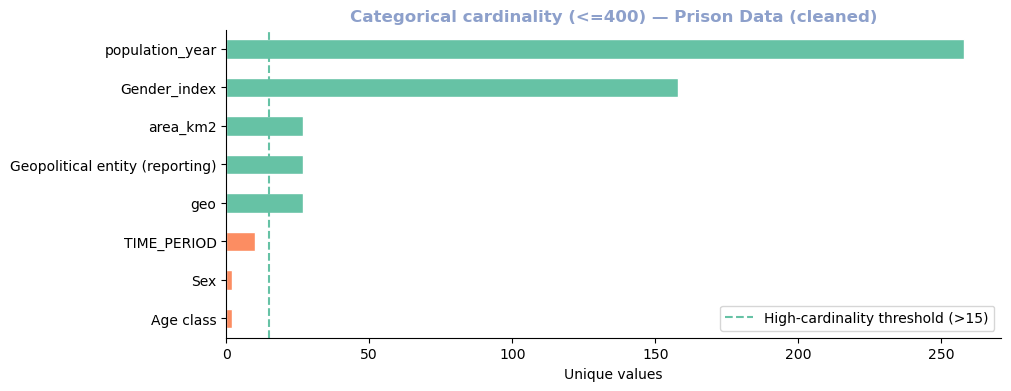

HIGH-CARDINALITY features (excluded from chart):
    'Per hundred thousand inhabitants': 828 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (cleaned)):
  'Age class' (2 values): ['Adult', 'Juvenile']

  'Sex' (2 values): ['Females', 'Males']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (27 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

  'area_km2' (27 values): ['110994', '131957'

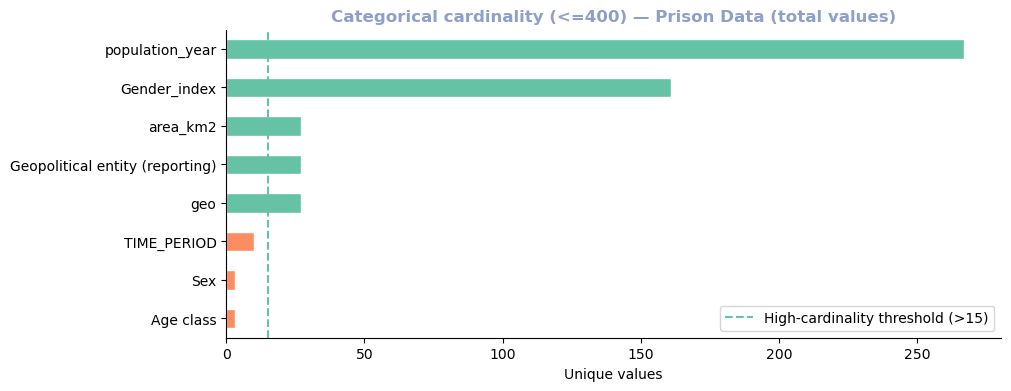

HIGH-CARDINALITY features (excluded from chart):
    'Per hundred thousand inhabitants': 1208 unique values — needs grouping/target encoding

  Reviewing unique values (Prison Data (total values)):
  'Age class' (3 values): ['Adult', 'Juvenile', 'Total']

  'Sex' (3 values): ['Females', 'Males', 'Total']

  'TIME_PERIOD' (10 values): ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']

  'geo' (27 values): ['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GRC', 'HRV', 'HUN', 'IRL', 'ITA', 'LTU', 'LUX', 'LVA', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE']

  'Geopolitical entity (reporting)' (27 values): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']

  'area_km2' (27 valu

In [38]:
inspect_categorical(prison_data, "Prison Data (cleaned)")
inspect_categorical(total_values, "Prison Data (total values)")

In [39]:
# Save the cleaned dataset in Data to export folder
prison_data.to_csv('../data/Data to export//cleaned_prison_data.csv', index=False)
total_values.to_csv('../data/Data to export//total_values_prison_data.csv', index=False)

In [40]:
# Parameters
TIME_PERIOD = 2014          # Anno disponibile: 2014-2023
SEX         = 'Females'     # Opzioni: 'Females', 'Males', 'Total'
AGE_CLASS   = 'Total'       # Opzioni: 'Adult', 'Juvenile', 'Total' 

# Validazione parametri
assert TIME_PERIOD in total_values['TIME_PERIOD'].unique(), \
    f"Anno non valido. Disponibili: {sorted(total_values['TIME_PERIOD'].unique())}"
assert SEX in total_values['Sex'].unique(), \
    f"Sesso non valido. Opzioni: {total_values['Sex'].unique().tolist()}"
assert AGE_CLASS in total_values['Age class'].unique(), \
    f"Age class non valida. Opzioni: {total_values['Age class'].unique().tolist()}"

filtered = total_values[
    (total_values['TIME_PERIOD'] == TIME_PERIOD) &
    (total_values['Sex']         == SEX)         &
    (total_values['Age class']   == AGE_CLASS)
]
# Aggrega per paese
agg = (
    filtered.groupby('Geopolitical entity (reporting)')['Per hundred thousand inhabitants']
    .mean()
    .reset_index()
)
agg.columns = ['country', 'value']
agg['value'] = agg['value'].round(1)
agg['iso3']  = agg['country'].map(country_codes)
agg = agg[agg['iso3'].notna()].copy()

print(f"Paesi con dati disponibili: {len(agg)}")
print(agg.sort_values('value', ascending=False).to_string(index=False))

# Mappa statica
fig = px.choropleth(
    agg,
    locations='iso3',
    color='value',
    hover_name='country',
    hover_data={'value': ':.1f', 'iso3': False},
    color_continuous_scale='YlOrRd',
    labels={'value': 'Per 100k abitanti'},
    title=f'Detenuti per 100.000 abitanti — Europa'
          f'<br><sup>Anno: {TIME_PERIOD} | Genere: {SEX} | Classe: {AGE_CLASS}</sup>',
    scope='europe',
)

fig.update_geos(
    visible=True, resolution=50,
    showcoastlines=True, coastlinecolor='#444',
    showland=True,  landcolor='#2d2d3e',
    showocean=True, oceancolor='#1a1a2e',
    showlakes=True, lakecolor='#1a1a2e',
    showframe=False,
    projection_type='natural earth',
    lataxis_range=[34, 72], lonaxis_range=[-25, 45],
    bgcolor='#1a1a2e',
)

fig.update_layout(
    title_font=dict(size=18, color='white'),
    paper_bgcolor='#1a1a2e',
    font=dict(color='white'),
    coloraxis_colorbar=dict(
        title=dict(text='Per 100k abitanti', font=dict(color='white', size=12)),
        tickfont=dict(color='white'),
        bgcolor='rgba(30,30,50,0.8)',
        bordercolor='#555', borderwidth=1,
        len=0.7, thickness=15,
    ),
    margin=dict(l=0, r=0, t=80, b=0),
    height=650,
)

# Disabilita interattività — mappa statica
fig.show(config={
    'staticPlot': True,       # nessun zoom/pan/hover
    'displayModeBar': False,  # nasconde la toolbar
})

Paesi con dati disponibili: 25
    country  value iso3
     Latvia   31.8  LVA
    Hungary   26.1  HUN
  Lithuania   23.9  LTU
   Slovakia   22.1  SVK
    Czechia   21.9  CZE
      Spain   20.8  ESP
      Malta   17.4  MLT
   Portugal   15.3  PRT
    Romania   15.1  ROU
     Poland   14.1  POL
    Austria   11.6  AUT
     Greece   10.2  GRC
 Luxembourg    9.5  LUX
    Germany    8.8  DEU
    Finland    8.7  FIN
   Slovenia    8.6  SVN
    Croatia    8.6  HRV
Netherlands    7.9  NLD
      Italy    7.6  ITA
   Bulgaria    7.0  BGR
     Sweden    6.9  SWE
     Cyprus    6.8  CYP
     France    6.2  FRA
    Ireland    5.2  IRL
    Denmark    5.1  DNK


In [41]:
# number of row of each country
for country in agg['country']:
    count = prison_data[prison_data['Geopolitical entity (reporting)'] == country].shape[0]
    print(f"{country}: {count} rows")

agg['country'].nunique()

Austria: 40 rows
Bulgaria: 40 rows
Croatia: 40 rows
Cyprus: 40 rows
Czechia: 40 rows
Denmark: 40 rows
Finland: 40 rows
France: 40 rows
Germany: 4 rows
Greece: 40 rows
Hungary: 40 rows
Ireland: 36 rows
Italy: 40 rows
Latvia: 40 rows
Lithuania: 40 rows
Luxembourg: 40 rows
Malta: 40 rows
Netherlands: 40 rows
Poland: 40 rows
Portugal: 36 rows
Romania: 40 rows
Slovakia: 40 rows
Slovenia: 36 rows
Spain: 40 rows
Sweden: 40 rows


25